Using device: NVIDIA GeForce RTX 2080
Reynolds Number: 100.0


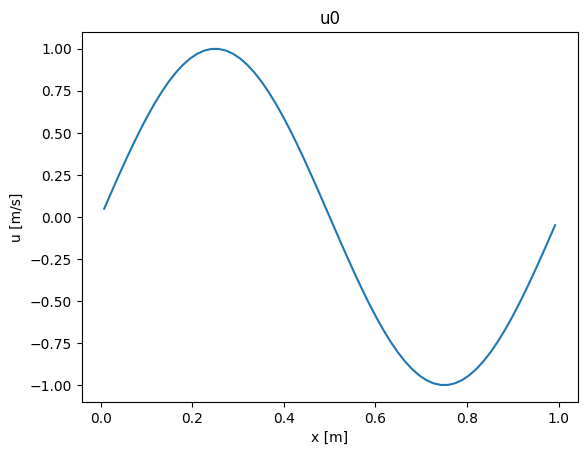

In [1]:
import numpy as np
import scipy
import torch
import pyflow
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

state_config = {
    'dtype': "float64",
    'device': "cuda",
    'Nx': 64,
    'DOMAIN_WIDTH': 1.0,
    'nu': 0.01,
    'CHARACTERISTIC_LENGTH': 1.0,
    'CHARACTERISTIC_SPEED': 1.0, 
}

fluid = pyflow.state.State1d(state_config)
u0 = torch.sin(2*torch.pi*fluid.coordinates) # [m/s]
fluid.velocity = u0

plt.plot(fluid.coordinates.cpu().numpy(), fluid.velocity.cpu().numpy())
plt.title("u0")
plt.xlabel("x [m]")
plt.ylabel("u [m/s]")
plt.show()

In [2]:
tf = 2 # [s]

solver_config = {
    'left_bc_type': "periodic",
    'right_bc_type': "periodic",
    'CFL_number': 0.8,
    'epsilon': 1e-12
}

solver = pyflow.solver.Solver1d(solver_config, fluid)
sol, t = solver.solve(duration=tf, save_intermediates=True, dimensional=True)
sol, t = sol.cpu().numpy(), t.cpu().numpy()

# Solver toggles fluid to a dimensionless state during the solution. Undoing that here so that everything is in a dimensional form.
fluid.dimensional() 

Simulating: 275steps [00:03, 74.87steps/s]


In [3]:
def analytical_burgers(x, t, nu, max_terms=1000):
    x = np.atleast_1d(x)
    is_scalar_time = np.isscalar(t)
    t = np.atleast_1d(t)
    X = x[np.newaxis, :]
    T = t[:, np.newaxis]
    z = 1.0 / (4.0 * np.pi * nu)
    denom = scipy.special.ive(0, z) * np.ones_like(X + T)
    num = np.zeros_like(X + T)
    for n in range(1, max_terms + 1):
        decay = np.exp(- (2 * np.pi * n)**2 * nu * T)
        bessel_term = scipy.special.ive(n, z)
        num += n * bessel_term * np.sin(2 * np.pi * n * X) * decay
        denom += 2 * bessel_term * np.cos(2 * np.pi * n * X) * decay    
    u = (8.0 * np.pi * nu * num) / denom
    if is_scalar_time:
        return u[0]
    return u
ana_sol = analytical_burgers(fluid.coordinates.cpu().numpy(), t, state_config["nu"])

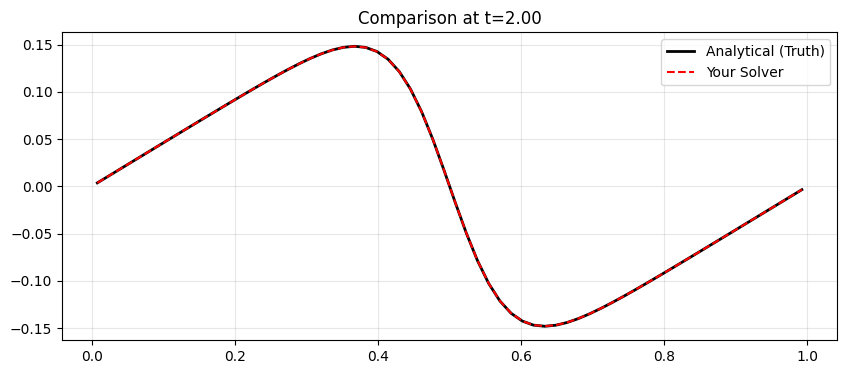

--- Error Metrics ---
Global MSE:                  4.6066e-06
Max Absolute Error:          2.2194e-02
Relative L2 Error (t_final): 4.6268e-04



In [4]:
t_comp=2 # [s]

t_idx = np.argmin(np.abs(t - t_comp)) 

plt.figure(figsize=(10, 4))
plt.plot(fluid.coordinates.cpu().numpy(), ana_sol[t_idx], 'k-', label='Analytical (Truth)', linewidth=2)
plt.plot(fluid.coordinates.cpu().numpy(), sol[t_idx], 'r--', label='Your Solver', linewidth=1.5)
plt.title(f"Comparison at t={t[t_idx]:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


mse = np.mean((sol - ana_sol)**2)
max_err = np.max(np.abs(sol - ana_sol))
L2_err_final = np.linalg.norm(sol[-1, :] - ana_sol[-1, :]) / np.linalg.norm(ana_sol[-1, :])

print("--- Error Metrics ---")
print(f"Global MSE:                  {mse:.4e}")
print(f"Max Absolute Error:          {max_err:.4e}")
print(f"Relative L2 Error (t_final): {L2_err_final:.4e}\n")

In [5]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Numerical Solution", "Analytical Solution"),
    specs=[[{'type': 'surface'}, {'type': 'surface'}]]
)

fig.add_trace(go.Surface(z=sol, x=fluid.coordinates.cpu().numpy(), y=t, colorscale='Viridis'), row=1, col=1)

fig.add_trace(go.Surface(z=ana_sol, x=fluid.coordinates.cpu().numpy(), y=t, colorscale='Viridis') ,row=1, col=2)

fig.update_layout(
    height=800,
    width=1000,
    scene=dict(
        xaxis_title='x [m]', yaxis_title='t [s]', zaxis_title='u [m/s]',
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8))
    ),
    scene2=dict(
        xaxis_title='x [m]', yaxis_title='t [s]', zaxis_title='u [m/s]',
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8))
    )
)
fig.show()